# Chess Strategy Recommender — Final Report

XGBoost model trained on Swiss chess tournaments from chess-results.com.  
Predicts performance rating (Rp) per strategic action (aggressive / solid / passive)  
to recommend round-by-round strategy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import shap

matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('imports OK')

imports OK


## 1. Data Volumes at Each Pipeline Stage

In [2]:
from pathlib import Path

# ── Pipeline stage counts ────────────────────────────────────────────────────
candidates = pd.read_csv('data/interim/tournament_candidates.csv')
n_candidates = len(candidates)

raw_html = list(Path('data/raw').glob('*.html'))
n_raw_files = len(raw_html)
n_raw_tournaments = len(set(f.stem.split('_')[0] for f in raw_html))

conn = sqlite3.connect('data/interim/chess.db')
n_db_tournaments = pd.read_sql('SELECT COUNT(*) AS n FROM tournaments', conn).iloc[0,0]
n_db_players     = pd.read_sql('SELECT COUNT(*) AS n FROM players_in_tournament', conn).iloc[0,0]
n_db_games       = pd.read_sql('SELECT COUNT(*) AS n FROM games', conn).iloc[0,0]
conn.close()

features        = pd.read_csv('data/processed/features.csv')
features_labeled = pd.read_csv('data/processed/features_labeled.csv')

stages = [
    ('scrape_discovery',  f'{n_candidates} tournament candidates',        n_candidates),
    ('scrape_tournaments',f'{n_raw_tournaments} tournaments / {n_raw_files} HTML files', n_raw_tournaments),
    ('parse → chess.db',  f'{n_db_tournaments} tournaments, {n_db_players} player-entries, {n_db_games} games', n_db_tournaments),
    ('build_features',    f'{len(features)} feature rows × {features.shape[1]} cols', len(features)),
    ('label',             f'{len(features_labeled)} labeled rows (action column added)', len(features_labeled)),
]

print(f'{"Stage":<22}  {"Count / Description"}')
print('-' * 70)
for stage, desc, _ in stages:
    print(f'{stage:<22}  {desc}')

Stage                   Count / Description
----------------------------------------------------------------------
scrape_discovery        150 tournament candidates
scrape_tournaments      150 tournaments / 450 HTML files
parse → chess.db        150 tournaments, 10253 player-entries, 37186 games
build_features          73182 feature rows × 24 cols
label                   66594 labeled rows (action column added)


## 2. Model Performance — MAE vs Baselines

In [3]:
report_text = Path('models/training_report.txt').read_text()
print(report_text)

CHESS PERFORMANCE RATING PREDICTOR — TRAINING REPORT

TRAIN / TEST SPLIT
  Train tournaments (118): 873076, 929420, 929422, 957150, 972273, 972588, 996752, 996753, 1003801, 1012287, 1012300, 1022294, 1030746, 1048008, 1048010, 1051218, 1051224, 1054159, 1054456, 1058057, 1059715, 1060848, 1063384, 1065413, 1065682, 1066445, 1066451, 1067907, 1069751, 1070842, 1071465, 1072504, 1072528, 1073951, 1074691, 1075548, 1075628, 1078111, 1079021, 1080372, 1080926, 1081512, 1082511, 1082918, 1083477, 1084221, 1085560, 1086367, 1086869, 1087732, 1088341, 1089908, 1090223, 1090879, 1090975, 1090985, 1092539, 1094232, 1208374, 1210514, 1210515, 1235671, 1241551, 1242846, 1251766, 1254861, 1258957, 1262787, 1263715, 1266603, 1275253, 1277112, 1277319, 1277321, 1277404, 1277432, 1277433, 1277628, 1278459, 1287555, 1292777, 1293523, 1296999, 1299458, 1299610, 1300160, 1300604, 1300653, 1300791, 1301587, 1303926, 1307620, 1307978, 1308129, 1308176, 1308177, 1309599, 1310916, 1312432, 1313075, 1313571,

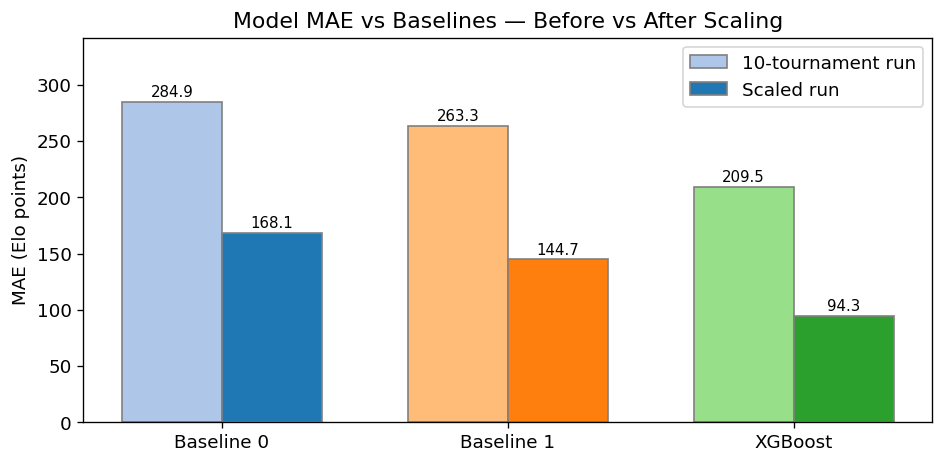

XGBoost improvement from scaling: +115.2 MAE points


In [4]:
import re

def _extract_mae(report: str, label: str) -> float:
    m = re.search(rf'{label}.*?MAE\s*=\s*([\d.]+)', report)
    return float(m.group(1)) if m else float('nan')

mae_b0  = _extract_mae(report_text, 'Baseline 0')
mae_b1  = _extract_mae(report_text, 'Baseline 1')
mae_xgb = _extract_mae(report_text, 'XGBoost')

# Results from the 10-tournament run (hardcoded baseline)
old = {'Baseline 0': 284.9, 'Baseline 1': 263.3, 'XGBoost': 209.5}
new = {'Baseline 0': mae_b0, 'Baseline 1': mae_b1, 'XGBoost': mae_xgb}

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
names = list(old.keys())
old_vals = [old[n] for n in names]
new_vals = [new[n] for n in names]
colors_old = ['#aec7e8', '#ffbb78', '#98df8a']
colors_new = ['#1f77b4', '#ff7f0e', '#2ca02c']
w = 0.35
bars1 = ax.bar(x - w/2, old_vals, w, label='10-tournament run', color=colors_old, edgecolor='grey')
bars2 = ax.bar(x + w/2, new_vals, w, label='Scaled run',        color=colors_new, edgecolor='grey')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('MAE (Elo points)')
ax.set_title('Model MAE vs Baselines — Before vs After Scaling')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(old_vals + new_vals) * 1.2)
plt.tight_layout()
plt.savefig('notebooks/mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

improvement = old['XGBoost'] - new['XGBoost']
print(f'XGBoost improvement from scaling: {improvement:+.1f} MAE points')

## 3. Feature Importance — Top 15 (Gain)

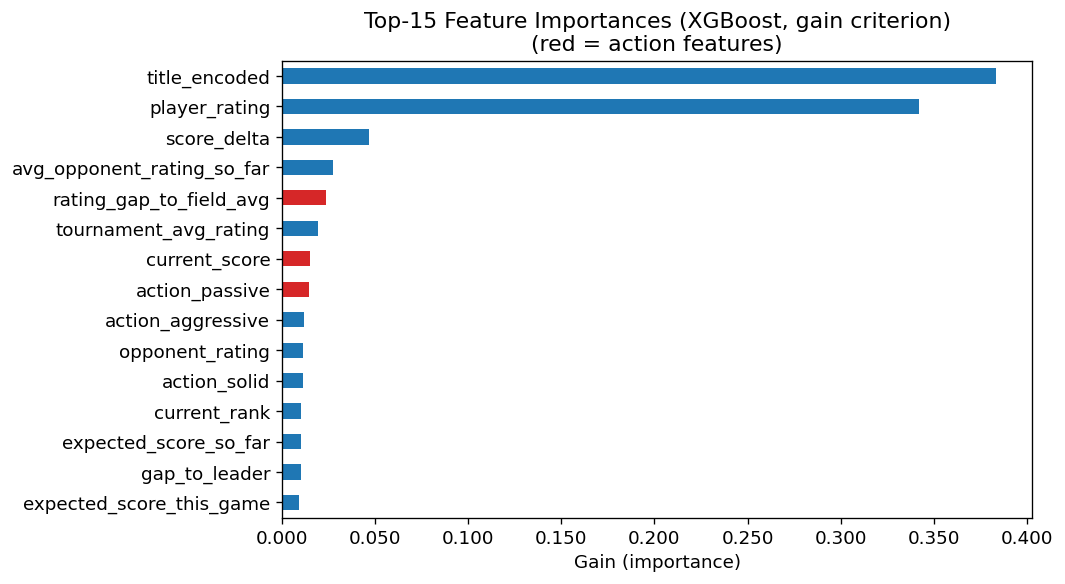

In [5]:
model = joblib.load('models/xgb_rp_predictor.pkl')

FEATURE_COLS = [
    'player_rating', 'title_encoded', 'seed_percentile',
    'tournament_avg_rating', 'tournament_rating_std',
    'n_rounds_total', 'field_size', 'rating_gap_to_field_avg',
    'round_number', 'rounds_remaining',
    'current_score', 'expected_score_so_far', 'score_delta',
    'avg_opponent_rating_so_far',
    'color_balance',
    'opponent_rating', 'rating_diff', 'expected_score_this_game',
    'playing_white', 'current_rank', 'gap_to_leader',
    'opponent_current_score',
    'action_aggressive', 'action_solid', 'action_passive',
]

importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if 'action' in f else '#1f77b4' for f in top15.index]
top15.plot.barh(ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Gain (importance)')
ax.set_title('Top-15 Feature Importances (XGBoost, gain criterion)\n(red = action features)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP Summary Plot

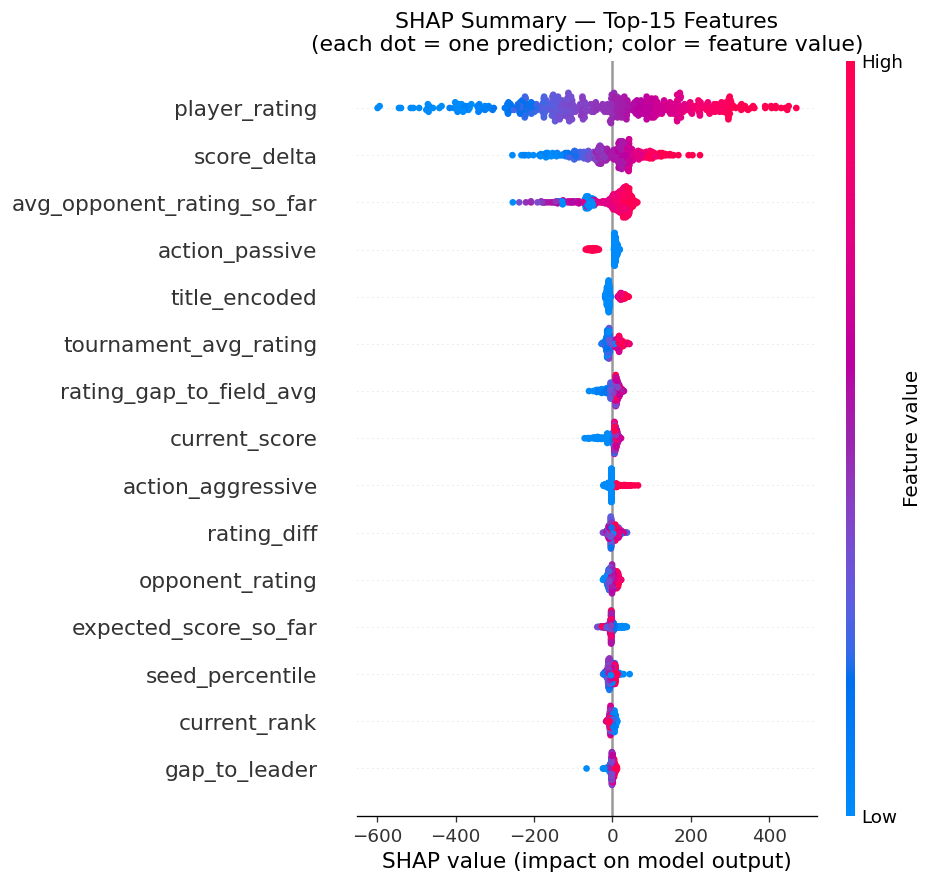

In [6]:
# Use a sample of the labeled data for SHAP (capped at 500 rows for speed)
df = pd.read_csv('data/processed/features_labeled.csv')
df['avg_opponent_rating_so_far'] = df['avg_opponent_rating_so_far'].fillna(0.0)
sample = df[FEATURE_COLS].sample(min(500, len(df)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, sample, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.title('SHAP Summary — Top-15 Features\n(each dot = one prediction; color = feature value)')
plt.tight_layout()
plt.savefig('notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Scenario Recommendations — Before vs After Scaling

Five realistic game situations tested against both the 10-tournament model and the scaled model.

In [7]:
from src.recommend import recommend

SCENARIOS = [
    ('S1 — Elite GM, R4/7 leading vs stronger (Black)',
     dict(player_rating=2500, opponent_rating=2580, round_num=4, n_rounds=7,
          current_score=2.5, gap_to_leader=0.0, playing_white=0,
          tournament_avg_rating=2350, tournament_rating_std=150,
          field_size=40, title_encoded=6)),

    ('S2 — Club 1800, R1/7 fresh start vs weaker (White)',
     dict(player_rating=1800, opponent_rating=1750, round_num=1, n_rounds=7,
          current_score=0.0, gap_to_leader=0.0, playing_white=1,
          tournament_avg_rating=1750, tournament_rating_std=120,
          field_size=50)),

    ('S3 — Must-win, R7/7 3/6 pts vs 2000 (White)',
     dict(player_rating=2200, opponent_rating=2000, round_num=7, n_rounds=7,
          current_score=3.0, gap_to_leader=-2.5, playing_white=1,
          tournament_avg_rating=2000, tournament_rating_std=200,
          field_size=80, title_encoded=4)),

    ('S4 — 1600 perfect 2/2, R3/9 paired up vs 1900 (Black)',
     dict(player_rating=1600, opponent_rating=1900, round_num=3, n_rounds=9,
          current_score=2.0, gap_to_leader=0.0, playing_white=0,
          tournament_avg_rating=1700, tournament_rating_std=180,
          field_size=100)),

    ('S5 — Mid-pack 2000, R5/7 2.5pts vs 2050 (Black)',
     dict(player_rating=2000, opponent_rating=2050, round_num=5, n_rounds=7,
          current_score=2.5, gap_to_leader=-1.0, playing_white=0,
          tournament_avg_rating=1900, tournament_rating_std=200,
          field_size=60, title_encoded=3)),
]

# Results from the 10-tournament run (captured before scaling)
BEFORE = [
    dict(recommended='aggressive', confidence='marginal', aggressive=2413, solid=2408, passive=2395),
    dict(recommended='solid',      confidence='marginal', aggressive=1719, solid=1721, passive=1656),
    dict(recommended='aggressive', confidence='marginal', aggressive=2025, solid=2025, passive=1999),
    dict(recommended='aggressive', confidence='strong',   aggressive=1804, solid=1760, passive=1726),
    dict(recommended='aggressive', confidence='marginal', aggressive=2022, solid=2010, passive=1981),
]

print(f'{'Scenario':<50}  {'Before':>12}  {'After':>12}  Agree?')
print('-' * 85)
for i, (name, kw) in enumerate(SCENARIOS):
    r_after  = recommend(**kw)
    r_before = BEFORE[i]
    agree = '✓' if r_after['recommended'] == r_before['recommended'] else '✗ CHANGED'
    rp_before = r_before[r_before['recommended']]
    rp_after  = r_after[r_after['recommended']]['predicted_rp']
    print(f"{name[:50]:<50}  {r_before['recommended'].upper():>5} ({rp_before:.0f})  {r_after['recommended'].upper():>5} ({rp_after:.0f})  {agree}")
print()

# Detailed output for each scenario
print('=' * 80)
print('DETAILED SCENARIO OUTPUTS (scaled model)')
print('=' * 80)
for name, kw in SCENARIOS:
    r = recommend(**kw)
    print(f'\n--- {name} ---')
    print(f"  Recommended: {r['recommended'].upper()}  ({r['confidence']})")
    print(f"  Aggressive={r['aggressive']['predicted_rp']:.0f}  "
          f"Solid={r['solid']['predicted_rp']:.0f}  "
          f"Passive={r['passive']['predicted_rp']:.0f}")
    print(f"  {r['explanation']}")

Scenario                                                  Before         After  Agree?
-------------------------------------------------------------------------------------
S1 — Elite GM, R4/7 leading vs stronger (Black)     AGGRESSIVE (2413)  SOLID (2522)  ✗ CHANGED
S2 — Club 1800, R1/7 fresh start vs weaker (White)  SOLID (1721)  AGGRESSIVE (1719)  ✗ CHANGED
S3 — Must-win, R7/7 3/6 pts vs 2000 (White)         AGGRESSIVE (2025)  SOLID (2032)  ✗ CHANGED
S4 — 1600 perfect 2/2, R3/9 paired up vs 1900 (Bla  AGGRESSIVE (1804)  AGGRESSIVE (1828)  ✓
S5 — Mid-pack 2000, R5/7 2.5pts vs 2050 (Black)     AGGRESSIVE (2022)  SOLID (1993)  ✗ CHANGED

DETAILED SCENARIO OUTPUTS (scaled model)

--- S1 — Elite GM, R4/7 leading vs stronger (Black) ---
  Recommended: SOLID  (marginal)
  Aggressive=2517  Solid=2522  Passive=2502
  Recommended SOLID — top 3 drivers: player_rating 2500.00 (shap +395.2), score_delta 0.39 (shap +45.4), avg_opponent_rating_so_far 2350.00 (shap +36.9)

--- S2 — Club 1800, R1/7 

## 6. Limitations

### Label heuristic noise
The action label (aggressive / solid / passive) is assigned heuristically from score-vs-expectation and opponent-rating-gap patterns within a round. This is a proxy for actual playing style — no move-level data (opening choice, piece activity, time usage) is available. Label noise directly limits the signal the model can learn about action effects.

### Swiss-specific scope  
All training data comes from Swiss-system tournaments. The model is not expected to generalise to round-robin events, team leagues, or match play, where the pairing dynamics and scoring incentives differ fundamentally.

### Small action vocabulary  
Three coarse action categories (aggressive / solid / passive) compress the full strategic space. A finer vocabulary (e.g. specific opening systems, time-pressure level, draw-offer timing) would require move-level data not available from chess-results.com.

### No move-level data  
chess-results.com provides only results and starting ratings — no PGN games. All features are derived from scores and pairings. Move-quality signals (engine evaluation, blunder rate, opening familiarity) are absent and likely important.

### Rp as a proxy for tournament success  
Performance rating (Rp) is a useful single-game signal but is not directly tied to prize/norm/ranking outcomes. Maximising round-by-round Rp does not always correspond to the optimal risk profile (e.g. a draw-offer in round 9 with a half-point lead might be optimal for a norm but sub-optimal for Rp).

### Temporal distribution shift  
Tournaments span 2023–2025. Rating inflation, compositional shifts in the tournament population, and player-pool changes across years may introduce distributional drift not captured in a static train/test split.